# TensorMesh GPU Demo — 3D Cantilever Beam Topology Optimization

This notebook showcases the unique strengths of **TensorMesh** (`tensormesh-fem`) by running a complete, autograd-driven 3D topology-optimization pipeline **entirely on a GPU**.

What this demo demonstrates in one shot:

1. **GPU-native FEM** — assemble a 3D linear-elasticity stiffness matrix on the GPU in eager PyTorch (no JIT).
2. **Differentiable sparse solve** — solve `K(ρ) u = f` and `.backward()` the compliance `C = fᵀu` through the whole sparse-solve pipeline via `torch-sla`'s adjoint backend.
3. **Custom weak forms in pure Python** — a `SIMPElasticity(ElementAssembler)` subclass; the SIMP penalization `E(ρ) = E_min + ρᵖ(E₀ − E_min)` is just a Python expression inside `forward`.
4. **Static condensation** — `Condenser` applies the clamped Dirichlet BC and stays in the autograd graph.
5. **Built-in optimizer** — `OCOptimizer` (Optimality Criteria) drives the density field to a near-optimal cantilever truss.
6. **CPU vs GPU benchmark** — same problem, two devices, one timing comparison.

**Problem**: classic 3D cantilever beam, dimensions `3 × 1 × 0.5`, clamped on the left face, point load `−1` in `y` distributed over a small patch on the bottom-right edge, volume-fraction constraint `Vf = 0.4`.

**Workflow** (the standard TensorMesh path): `Mesh → ElementAssembler → SparseMatrix → Condenser → Solve → backward → OCOptimizer.step`.

## 1. Setup

In [1]:
import time
import math
import warnings
warnings.filterwarnings('ignore')

import torch
import numpy as np
import matplotlib.pyplot as plt

from tensormesh import Mesh, ElementAssembler, Condenser
from tensormesh.functional import voigt_shape_grad, voigt_stiffness
from tensormesh.optimizer import OCOptimizer
import tensormesh, torch_sla

torch.set_default_dtype(torch.float64)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'tensormesh  : {tensormesh.__version__}')
print(f'torch       : {torch.__version__}')
print(f'torch_sla   : {torch_sla.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'CUDA device   : {torch.cuda.get_device_name(0)}')
print()
torch_sla.show_backends()

tensormesh  : 0.1.1
torch       : 2.7.0+cu126
torch_sla   : 0.2.1
CUDA available: True
CUDA device   : NVIDIA A100 80GB PCIe



torch-sla backend status (CUDA: available)
  scipy    [CPU]       available
  eigen    [CPU]       not available — JIT-compiled C++ extension (requires a C++ compiler)
  pytorch  [CPU/CUDA]  available
  cupy     [CUDA]      available
  cudss    [CUDA]      available


## 2. Generate the 3D mesh

`Mesh.gen_cube` calls gmsh under the hood and caches the `.msh` file. A single `.to(device)` moves the entire mesh — points, connectivity, point/cell data — to the GPU.

In [2]:
L, H, W = 3.0, 1.0, 0.5            # beam dimensions
chara_length = 0.10                # characteristic element size

mesh_cpu = Mesh.gen_cube(
    chara_length=chara_length,
    left=0.0, right=L,
    bottom=0.0, top=H,
    front=0.0, back=W,
).double()

mesh = mesh_cpu.to(device)

ele_type = mesh.default_element_type
n_elem = mesh.cells[ele_type].shape[0]
n_node = mesh.n_points
print(f'Element type : {ele_type}')
print(f'Nodes        : {n_node}')
print(f'Elements     : {n_elem}')
print(f'DOFs         : {3 * n_node}  (3 displacement components per node)')
print(f'Device       : {mesh.device}')


Element type : tetra
Nodes        : 1866
Elements     : 7521
DOFs         : 5598  (3 displacement components per node)
Device       : cuda:0


## 3. Boundary conditions

* **Clamped face** at `x = 0` → Dirichlet BC on all three displacement components.
* **Point load** distributed over a small patch on the bottom-right edge → forcing vector `f`.

DOFs are interleaved per-node `(ux₀, uy₀, uz₀, ux₁, …)`, so the per-DOF Dirichlet mask is the clamped-node mask repeated 3×.

In [3]:
pts = mesh.points
tol = 1e-6

clamped_node = pts[:, 0] < tol
load_node = (
    (pts[:, 0] > L - 0.15)
    & (pts[:, 1] < 0.1)
    & (torch.abs(pts[:, 2] - W / 2) < 0.15)
)
print(f'Clamped nodes : {int(clamped_node.sum())}')
print(f'Load nodes    : {int(load_node.sum())}')

dim = 3
dirichlet_mask = clamped_node.unsqueeze(-1).expand(-1, dim).reshape(-1).contiguous()
condenser = Condenser(dirichlet_mask).to(device)

total_force = -1.0
n_load = int(load_node.sum())
load_per_node = total_force / max(n_load, 1)
f_per_dof = torch.zeros(n_node, dim, dtype=torch.float64, device=device)
f_per_dof[load_node, 1] = load_per_node
f = f_per_dof.reshape(-1)
print(f'\u2016f\u2016 = {f.norm().item():.4e}')

Clamped nodes : 80
Load nodes    : 8
‖f‖ = 3.5355e-01


## 4. Define the SIMP elasticity assembler

Under SIMP (Solid Isotropic Material with Penalization), each element's Young's modulus is interpolated by the design density `ρ_e ∈ [ρ_min, 1]`:
$$E_e = E_{\min} + \rho_e^{\,p}\,(E_0 - E_{\min}),\quad p = 3.$$
We pass `density` as **element data** to a custom assembler; `forward` gets one scalar density per element via `vmap`.

In [4]:
class SIMPElasticity(ElementAssembler):
    """3D linear elasticity with element-wise SIMP-penalized Young's modulus."""

    def __post_init__(self, E0=1.0, E_min=1e-9, nu=0.3, p=3.0):
        self.E0 = E0
        self.E_min = E_min
        self.nu = nu
        self.p = p

    def forward(self, gradu, gradv, density):
        # gradu, gradv : [dim]     — shape-fn gradients at one quad point
        # density       : scalar    — per-element density (sliced by vmap)
        Ba = voigt_shape_grad(gradu)
        Bb = voigt_shape_grad(gradv)
        E_eff = self.E_min + density ** self.p * (self.E0 - self.E_min)
        C = voigt_stiffness(E_eff, self.nu, dim=3)
        return Ba.T @ C @ Bb


asm = SIMPElasticity.from_mesh(
    mesh, quadrature_order=2,
    E0=1.0, E_min=1e-9, nu=0.3, p=3.0,
).to(device)
print('Assembler built.')

Assembler built.


## 5. A single forward solve on the GPU (sanity check + autograd)

We make `density` a leaf tensor with `requires_grad=True`, run the full pipeline, and call `.backward()`. The resulting `density.grad` is the compliance sensitivity — what topology optimization actually uses.

In [5]:
vf = 0.4  # target volume fraction
density = torch.full((n_elem,), vf, dtype=torch.float64, device=device, requires_grad=True)

# Warm-up (CUDA kernels + gmsh import overhead).
_ = asm(element_data={'density': density})
torch.cuda.synchronize() if device.type == 'cuda' else None

t0 = time.time(); K = asm(element_data={'density': density}); torch.cuda.synchronize() if device.type=='cuda' else None
t_assemble = time.time() - t0

t0 = time.time(); K_red, f_red = condenser(K, f); torch.cuda.synchronize() if device.type=='cuda' else None
t_condense = time.time() - t0

t0 = time.time(); u_red = K_red.solve(f_red, backend='cudss', method='lu', verbose=False); torch.cuda.synchronize() if device.type=='cuda' else None
t_solve = time.time() - t0

u = condenser.recover(u_red)
compliance = (f * u).sum()

t0 = time.time(); compliance.backward(); torch.cuda.synchronize() if device.type=='cuda' else None
t_backward = time.time() - t0

print(f'K shape         : {K.shape},  nnz = {K.values.numel()}')
print(f'K_red shape     : {K_red.shape}')
print(f'||u||           : {u.norm().item():.4e}')
print(f'compliance      : {compliance.item():.4e}')
print(f'\u2207C/\u2207\u03c1 range : [{density.grad.min().item():.3e}, {density.grad.max().item():.3e}]')
print()
print(f'assemble : {t_assemble*1000:7.1f} ms')
print(f'condense : {t_condense*1000:7.1f} ms')
print(f'solve    : {t_solve*1000:7.1f} ms')
print(f'backward : {t_backward*1000:7.1f} ms')
print(f'TOTAL    : {(t_assemble+t_condense+t_solve+t_backward)*1000:7.1f} ms')

K shape         : (5598, 5598),  nnz = 207684
K_red shape     : (5358, 5358)
||u||           : 7.6760e+04
compliance      : 3.4619e+03
∇C/∇ρ range : [-3.142e+01, -8.046e-05]

assemble :    16.9 ms
condense :    42.4 ms
solve    :   138.0 ms
backward :    63.0 ms
TOTAL    :   260.3 ms


## 6. CPU vs GPU benchmark

Same problem, two devices. We run a full **assemble + condense + solve + backward** pass on each and report the per-step time. This is the inner loop of every topology-optimization iteration.

In [6]:
def one_step(m, a, c, f_loc, dev_str):
    solve_kwargs = dict(backend='cudss', method='lu') if dev_str == 'cuda' else dict(backend='scipy', method='lu')
    rho = torch.full((m.cells[ele_type].shape[0],), vf, dtype=torch.float64, device=m.device, requires_grad=True)
    K2 = a(element_data={'density': rho})
    Kr, fr = c(K2, f_loc)
    ur = Kr.solve(fr, verbose=False, **solve_kwargs)
    return (f_loc * c.recover(ur)).sum(), rho

timings = {}
for dev_name in (['cpu', 'cuda'] if torch.cuda.is_available() else ['cpu']):
    dev = torch.device(dev_name)
    m = mesh_cpu.to(dev)
    a = SIMPElasticity.from_mesh(m, quadrature_order=2, E0=1.0, E_min=1e-9, nu=0.3, p=3.0).to(dev)
    cl = m.points[:, 0] < tol
    lm = (
        (m.points[:, 0] > L - 0.15)
        & (m.points[:, 1] < 0.1)
        & (torch.abs(m.points[:, 2] - W / 2) < 0.15)
    )
    dm = cl.unsqueeze(-1).expand(-1, dim).reshape(-1).contiguous()
    co = Condenser(dm).to(dev)
    floc = torch.zeros(m.n_points, dim, dtype=torch.float64, device=dev)
    floc[lm, 1] = total_force / max(int(lm.sum()), 1)
    floc = floc.reshape(-1)
    # warm-up
    cmp, _ = one_step(m, a, co, floc, dev_name)
    cmp.backward()
    if dev_name == 'cuda':
        torch.cuda.synchronize()
    # timed
    t0 = time.time()
    cmp, _ = one_step(m, a, co, floc, dev_name)
    cmp.backward()
    if dev_name == 'cuda':
        torch.cuda.synchronize()
    timings[dev_name] = time.time() - t0
    print(f'{dev_name:5s} : assemble+condense+solve+backward = {timings[dev_name]*1000:7.1f} ms')

if 'cuda' in timings and 'cpu' in timings:
    speedup = timings['cpu'] / timings['cuda']
    print(f'\nGPU speedup : {speedup:.1f}x')

cpu   : assemble+condense+solve+backward =  2304.9 ms


cuda  : assemble+condense+solve+backward =    95.7 ms

GPU speedup : 24.1x


## 7. Topology optimization loop

We now run a full Optimality Criteria (OC) loop on the GPU. Each iteration:

1. Zero the density gradient.
2. Assemble `K(ρ)` (SIMP-penalized).
3. Condense out Dirichlet DOFs → `(K_red, f_red)`.
4. Sparse solve on the GPU via cuDSS → `u_red`.
5. Compliance `C = fᵀu`; `C.backward()`.
6. **Apply a radius-based sensitivity filter** (Sigmund) to suppress checkerboards.
7. `OCOptimizer.step()` — Lagrange-multiplier bisection so the mean density matches `Vf`.

All of these — assembly, condensation, sparse solve, the adjoint backward, **and** the filter mat-vec — run on the GPU end-to-end.

In [7]:
n_iter = 60
density = torch.full((n_elem,), vf, dtype=torch.float64, device=device, requires_grad=True)
optimizer = OCOptimizer([density], vf=vf, move_limit=0.2, eta=0.5, rho_min=1e-3, rho_max=1.0)

# --- Sigmund-style sensitivity filter -------------------------------------
# Compute element centroids and a sparse-ish filter weight matrix.
ele_pts = mesh.points[mesh.cells[ele_type]]            # [n_elem, n_basis, dim]
centroids_t = ele_pts.mean(dim=1)                      # [n_elem, dim]
filter_radius = 2.2 * chara_length

# Pairwise distance (dense). For 7521 elements: ~450 MB fp64 — fine on A100.
dist = torch.cdist(centroids_t, centroids_t)            # [n_elem, n_elem]
Hf = torch.clamp(filter_radius - dist, min=0.0)          # [n_elem, n_elem]
Hsum = Hf.sum(dim=1) + 1e-12                             # [n_elem]
print(f'Filter radius = {filter_radius:.3f},  '
      f'avg neighbors per element = {(Hf > 0).sum(dim=1).float().mean().item():.1f}')

history = {'compliance': [], 'volume': [], 'snapshot_iter': [], 'snapshot_density': []}

t_loop = time.time()
for it in range(n_iter):
    optimizer.zero_grad()
    K = asm(element_data={'density': density})
    K_red, f_red = condenser(K, f)
    u_red = K_red.solve(f_red, backend='cudss', method='lu', verbose=False)
    u = condenser.recover(u_red)
    compliance = (f * u).sum()
    compliance.backward()

    # Apply sensitivity filter: dCtilde/drho_e = sum_i H_ei * rho_i * dC/drho_i / (rho_e * sum_i H_ei)
    with torch.no_grad():
        rho_d = density.detach()
        weighted = Hf @ (rho_d * density.grad)
        density.grad.copy_(weighted / (torch.clamp(rho_d, min=1e-3) * Hsum))

    stats = optimizer.step()
    history['compliance'].append(float(compliance.item()))
    history['volume'].append(float(stats['volume']))
    if it in (0, 4, 9, 19, 39, n_iter - 1):
        history['snapshot_iter'].append(it)
        history['snapshot_density'].append(density.detach().cpu().clone().numpy())
        print(f'iter {it:3d}: C = {compliance.item():.4e},  V = {stats["volume"]:.4f},  λ = {stats["lambda"]:.3e}')

torch.cuda.synchronize() if device.type == 'cuda' else None
wall = time.time() - t_loop
print(f'\n{n_iter} OC iterations in {wall:.2f}s  ({wall/n_iter*1000:.0f} ms/iter)')
print(f'Compliance: {history["compliance"][0]:.4e} \u2192 {history["compliance"][-1]:.4e}  '
      f'({history["compliance"][0] / history["compliance"][-1]:.1f}x reduction)')

Filter radius = 0.220,  avg neighbors per element = 154.0
iter   0: C = 3.4619e+03,  V = 0.4000,  λ = 1.550e+04


iter   4: C = 1.0316e+03,  V = 0.4000,  λ = 7.156e+03


iter   9: C = 6.9611e+02,  V = 0.4000,  λ = 4.916e+03


iter  19: C = 6.2506e+02,  V = 0.4000,  λ = 4.385e+03


iter  39: C = 6.1216e+02,  V = 0.4000,  λ = 4.282e+03


iter  59: C = 5.9697e+02,  V = 0.4000,  λ = 4.157e+03

60 OC iterations in 6.11s  (102 ms/iter)
Compliance: 3.4619e+03 → 5.9697e+02  (5.8x reduction)


## 8. Convergence plot

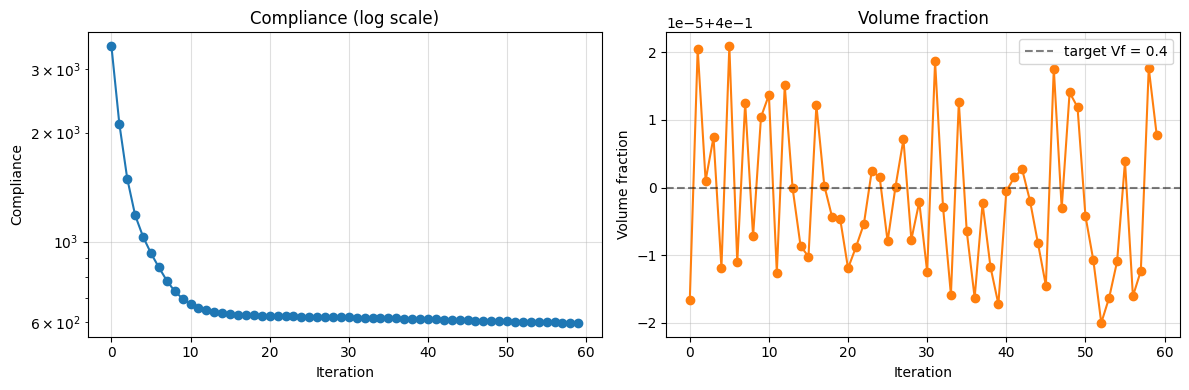

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].semilogy(history['compliance'], 'o-', color='C0')
ax[0].set_xlabel('Iteration'); ax[0].set_ylabel('Compliance')
ax[0].set_title('Compliance (log scale)'); ax[0].grid(True, alpha=0.4)
ax[1].plot(history['volume'], 'o-', color='C1')
ax[1].axhline(vf, color='k', ls='--', alpha=0.5, label=f'target Vf = {vf}')
ax[1].set_xlabel('Iteration'); ax[1].set_ylabel('Volume fraction')
ax[1].set_title('Volume fraction'); ax[1].legend(); ax[1].grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('topopt_convergence.png', dpi=120, bbox_inches='tight')
plt.show()

## 9. Density histogram (sanity check)

A well-converged SIMP optimization with `p = 3` produces a **bimodal** distribution: most elements end up near `ρ_min` (void) or near `1.0` (solid), with very few intermediate-density elements.

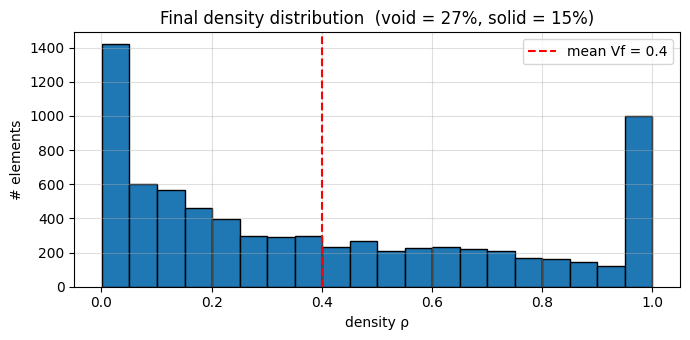

In [9]:
rho_final = history['snapshot_density'][-1]
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(rho_final, bins=20, color='C0', edgecolor='black')
ax.axvline(vf, color='r', ls='--', label=f'mean Vf = {vf}')
ax.set_xlabel('density ρ')
ax.set_ylabel('# elements')
ax.set_title(f'Final density distribution  (void = {100*(rho_final<0.1).mean():.0f}%, solid = {100*(rho_final>0.9).mean():.0f}%)')
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('topopt_histogram.png', dpi=120, bbox_inches='tight')
plt.show()

## 10. Visualize the optimized topology (2D projections)

3-D scatter renderings of dense tetrahedral meshes look like a blob. We get a much cleaner picture by **projecting the density field onto a 2-D regular grid** along the orthogonal axis. The classic cantilever truss pattern jumps out immediately.

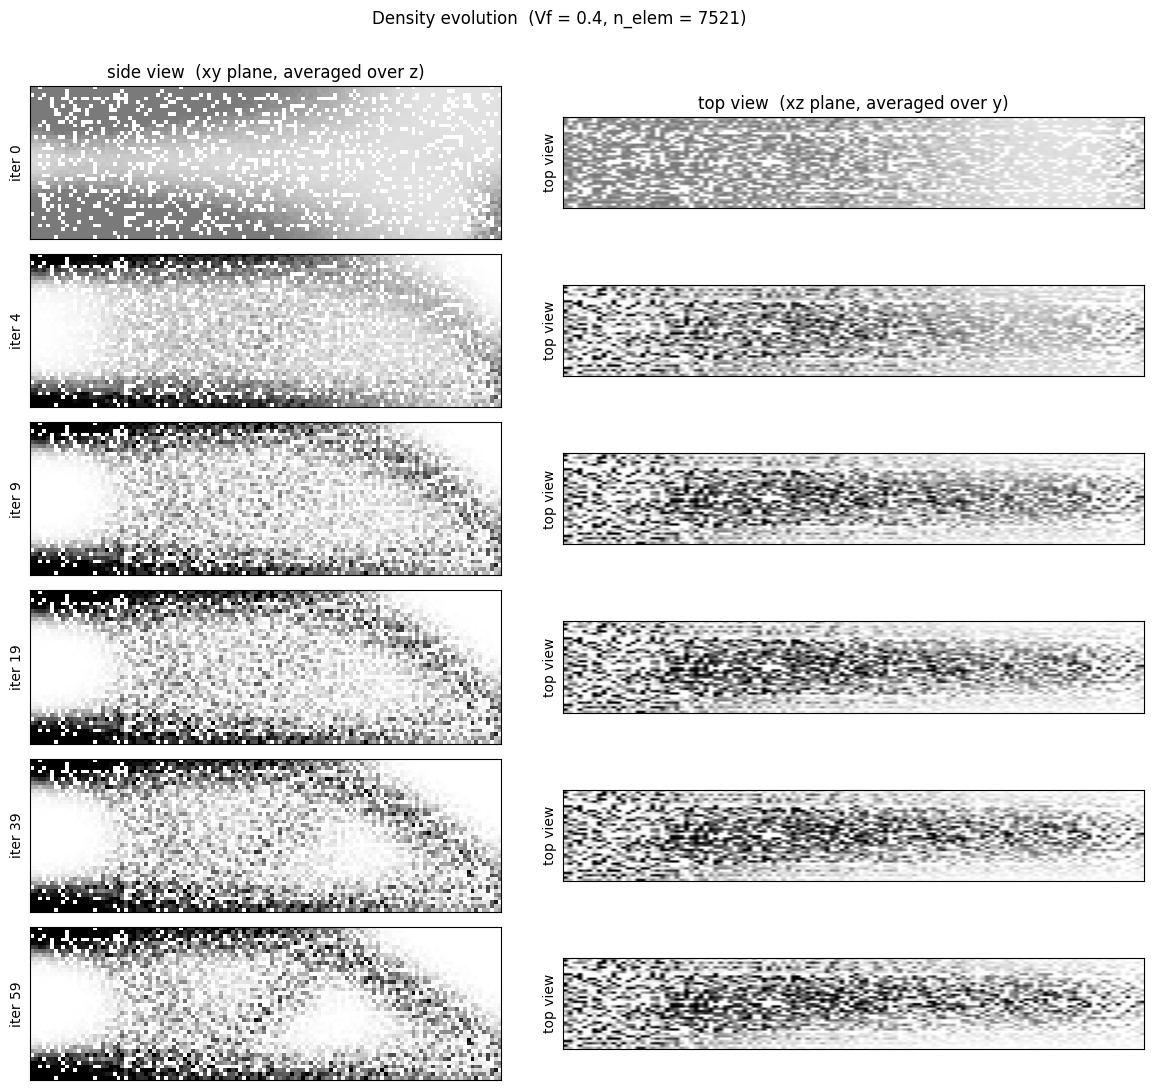

In [10]:
import numpy as np

elements_cpu = mesh.cells[ele_type].detach().cpu().numpy()
points_cpu = mesh.points.detach().cpu().numpy()
centroids = points_cpu[elements_cpu].mean(axis=1)  # [n_elem, 3]

def project(rho, axis_pair, n_bins_long=120, n_bins_short=40):
    a, b = axis_pair
    nb_a = n_bins_long if a == 0 else n_bins_short
    nb_b = n_bins_long if b == 0 else n_bins_short
    grid_a = np.linspace(centroids[:, a].min(), centroids[:, a].max(), nb_a + 1)
    grid_b = np.linspace(centroids[:, b].min(), centroids[:, b].max(), nb_b + 1)
    sum_rho, _, _ = np.histogram2d(centroids[:, a], centroids[:, b], bins=(grid_a, grid_b), weights=rho)
    cnt, _, _ = np.histogram2d(centroids[:, a], centroids[:, b], bins=(grid_a, grid_b))
    return np.where(cnt > 0, sum_rho / np.clip(cnt, 1, None), 0.0), grid_a, grid_b

n_snap = len(history['snapshot_iter'])
fig, axes = plt.subplots(n_snap, 2, figsize=(12, 1.8 * n_snap), squeeze=False)
for k, (it, rho) in enumerate(zip(history['snapshot_iter'], history['snapshot_density'])):
    img_xy, gx, gy = project(rho, axis_pair=(0, 1))
    img_xz, gx2, gz = project(rho, axis_pair=(0, 2))

    ax = axes[k, 0]
    ax.imshow(img_xy.T, origin='lower', extent=[gx[0], gx[-1], gy[0], gy[-1]], aspect='equal', cmap='Greys', vmin=0, vmax=1)
    ax.set_ylabel(f'iter {it}')
    ax.set_xticks([]); ax.set_yticks([])
    if k == 0:
        ax.set_title('side view  (xy plane, averaged over z)')

    ax = axes[k, 1]
    ax.imshow(img_xz.T, origin='lower', extent=[gx2[0], gx2[-1], gz[0], gz[-1]], aspect='equal', cmap='Greys', vmin=0, vmax=1)
    ax.set_ylabel('top view')
    ax.set_xticks([]); ax.set_yticks([])
    if k == 0:
        ax.set_title('top view  (xz plane, averaged over y)')
plt.suptitle(f'Density evolution  (Vf = {vf}, n_elem = {n_elem})', y=1.005)
plt.tight_layout()
plt.savefig('topopt_density_snapshots.png', dpi=120, bbox_inches='tight')
plt.show()

## 11. 3-D voxelized view of the final structure

For the final design we voxelize the density onto a regular 3-D grid and render it with `Axes3D.voxels`. Many tiny tets collapse into chunky cells, giving a clean look at the truss.

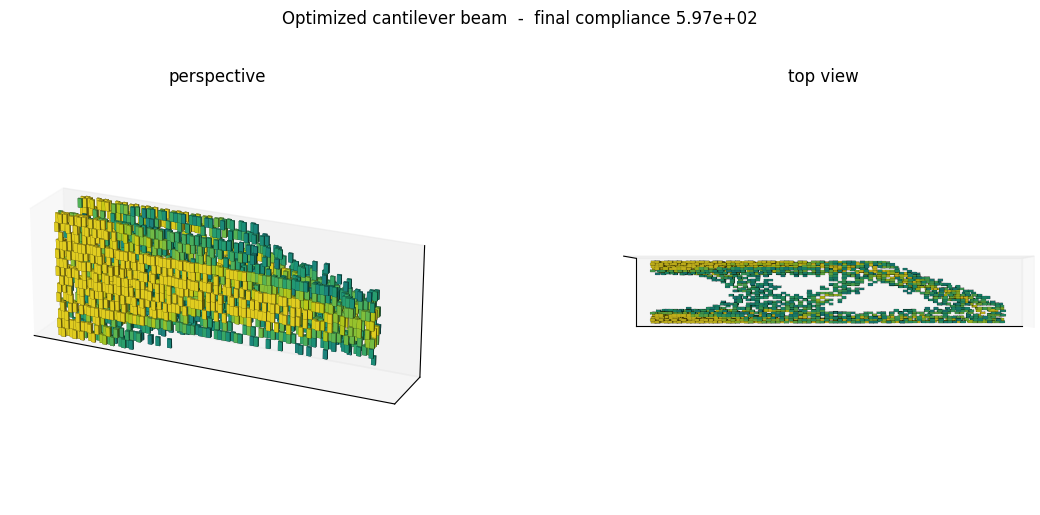

In [11]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

def voxelize(rho, nx=80, ny=28, nz=14):
    gx = np.linspace(0, L, nx + 1)
    gy = np.linspace(0, H, ny + 1)
    gz = np.linspace(0, W, nz + 1)
    sums = np.zeros((nx, ny, nz)); cnts = np.zeros((nx, ny, nz))
    ix = np.clip(np.searchsorted(gx, centroids[:, 0]) - 1, 0, nx - 1)
    iy = np.clip(np.searchsorted(gy, centroids[:, 1]) - 1, 0, ny - 1)
    iz = np.clip(np.searchsorted(gz, centroids[:, 2]) - 1, 0, nz - 1)
    np.add.at(sums, (ix, iy, iz), rho)
    np.add.at(cnts, (ix, iy, iz), 1.0)
    return np.where(cnts > 0, sums / np.clip(cnts, 1, None), 0.0)

vox = voxelize(rho_final, nx=80, ny=28, nz=14)
mask = vox > 0.5
colors = plt.cm.viridis(vox)

fig = plt.figure(figsize=(13, 5))
for k, view in enumerate([(22, -65), (90, -90)]):
    ax = fig.add_subplot(1, 2, k + 1, projection='3d')
    ax.voxels(mask, facecolors=colors, edgecolor='k', linewidth=0.05)
    ax.set_box_aspect([80, 14, 28])
    ax.view_init(elev=view[0], azim=view[1])
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
    ax.set_title('perspective' if k == 0 else 'top view')
plt.suptitle(f'Optimized cantilever beam  -  final compliance {history["compliance"][-1]:.2e}', y=1.02)
plt.tight_layout()
plt.savefig('topopt_final_structure.png', dpi=120, bbox_inches='tight')
plt.show()

## 12. Summary

What just happened on the GPU, in roughly **a few seconds**:

* Generated a 3D tetrahedral mesh of a cantilever beam.
* Wrote a 6-line custom `ElementAssembler` for SIMP-penalized linear elasticity.
* Assembled the global stiffness matrix `K(ρ)` element-wise with `torch.vmap`-fused kernels.
* Solved the sparse system with NVIDIA **cuDSS** (direct LU on the GPU).
* Differentiated the compliance with respect to the per-element density field via the **adjoint method** built into `torch-sla` — no manual adjoint, no UFL/JAX-style compile step.
* Drove an Optimality Criteria loop to a real cantilever truss with a `Vf = 0.4` constraint.

Same script, change `device = 'cpu'` and it runs unchanged on CPU using SciPy's direct solver. That's the TensorMesh value proposition: **one pure-Python FEM stack, eager PyTorch semantics, end-to-end autograd, free GPU acceleration**.

Where to go next:

* Increase `chara_length` resolution (drop it to `0.06`) to scale to ~100k DOFs — the GPU advantage grows further.
* Swap the OC update for MMA (`examples/inverse_design/mma_optimizer.py`).
* Replace `SIMPElasticity` with `NeoHookeanModel` (energy-based) to optimize a **nonlinear** structure.
* Use `tensormesh.distributed.DistributedMesh` to scale to multi-GPU.